In [2]:
import pandas as pd

df = pd.read_csv('../data/Q_75_previous-1950-2024_RR-T-Vent.csv.gz', 
                  sep=';', 
                  compression='gzip')

df.head()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,HXI2,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR
0,75101001,INNOCENTS,48.860667,2.348333,37,19500101,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75101001,INNOCENTS,48.860667,2.348333,37,19500102,1.8,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75101001,INNOCENTS,48.860667,2.348333,37,19500103,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,75101001,INNOCENTS,48.860667,2.348333,37,19500104,0.2,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,75101001,INNOCENTS,48.860667,2.348333,37,19500105,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import os

# List all files in the data folder
for f in sorted(os.listdir('../data')):
    print(f)

H_75_1990-1999.csv.gz
H_75_2000-2009.csv.gz
H_75_2010-2019.csv.gz
H_75_latest-2025-2026.csv.gz
H_75_previous-2020-2024.csv.gz
H_93_1990-1999.csv.gz
H_93_2000-2009.csv.gz
H_93_2010-2019.csv.gz
H_93_latest-2025-2026.csv.gz
H_93_previous-2020-2024.csv.gz
Q_75_latest-2025-2026_RR-T-Vent.csv.gz
Q_75_latest-2025-2026_autres-parametres.csv.gz
Q_75_previous-1950-2024_RR-T-Vent.csv.gz
Q_75_previous-1950-2024_autres-parametres.csv.gz
Q_93_latest-2025-2026_RR-T-Vent.csv.gz
Q_93_latest-2025-2026_autres-parametres.csv.gz
Q_93_previous-1950-2024_RR-T-Vent.csv.gz
Q_93_previous-1950-2024_autres-parametres.csv.gz


In [4]:


station_counts = (
    df.groupby(['NUM_POSTE', 'NOM_USUEL'])
      .size()
      .reset_index(name='n_records')
      .sort_values('n_records', ascending=False)
)

station_counts.head(10)

,NUM_POSTE,NOM_USUEL,n_records
16,75114001,PARIS-MONTSOURIS,27394
8,75110001,LARIBOISIERE,26104
13,75112004,ST-ANTOINE,26078
23,75116002,BAGATELLE,25897
10,75112001,ILE DE BERCY,25366
3,75106001,LUXEMBOURG,24290
29,75119001,BUTTES CHAUMONT,22957
11,75112002,LA FAISANDERIE,21382
24,75116003,PASSY,20396
20,75115001,VAUGIRARD,20127


In [5]:


df_pm = df[df['NUM_POSTE'] == 75114001].copy()

df_pm[['NUM_POSTE', 'NOM_USUEL']].drop_duplicates()

,NUM_POSTE,NOM_USUEL
248351,75114001,PARIS-MONTSOURIS


In [6]:


df_pm['DATE'] = pd.to_datetime(
    df_pm['AAAAMMJJ'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

print('Start date:', df_pm['DATE'].min())
print('End date:', df_pm['DATE'].max())
print('Number of rows:', len(df_pm))
print('Missing DATE values:', df_pm['DATE'].isna().sum())
print('Missing RR values:', df_pm['RR'].isna().sum())
print('Negative RR values:', (df_pm['RR'] < 0).sum())

df_pm['QRR'].value_counts(dropna=False).sort_index()

Start date: 1950-01-01 00:00:00
End date: 2024-12-31 00:00:00
Number of rows: 27394
Missing DATE values: 0
Missing RR values: 0
Negative RR values: 0


QRR
0.0        1
1.0    27393
Name: count, dtype: int64

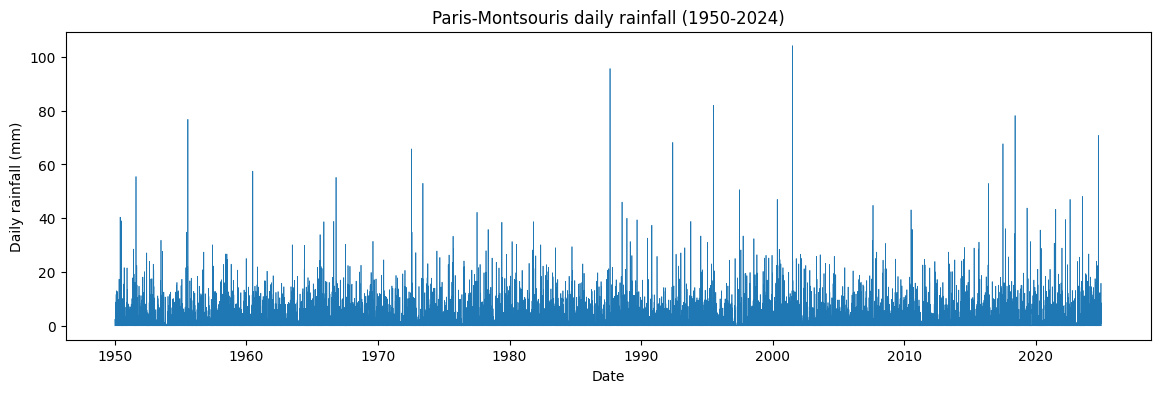

In [7]:


import matplotlib.pyplot as plt

df_pm = df_pm.sort_values('DATE')

plt.figure(figsize=(14, 4))
plt.plot(df_pm['DATE'], df_pm['RR'], linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('Daily rainfall (mm)')
plt.title('Paris-Montsouris daily rainfall (1950-2024)')
plt.show()

In [8]:
df_h = pd.read_csv('../data/H_75_2000-2009.csv.gz', sep=';', compression='gzip')
df_h.head()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJHH,RR1,QRR1,DRR1,QDRR1,...,INS,QINS,INS2,QINS2,TLAGON,QTLAGON,TVEGETAUX,QTVEGETAUX,ECOULEMENT,QECOULEMENT
0,75104001,TOUR ST-JACQUES,48.858333,2.348333,38,2000010100,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75104001,TOUR ST-JACQUES,48.858333,2.348333,38,2000010101,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75104001,TOUR ST-JACQUES,48.858333,2.348333,38,2000010102,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,75104001,TOUR ST-JACQUES,48.858333,2.348333,38,2000010103,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,75104001,TOUR ST-JACQUES,48.858333,2.348333,38,2000010104,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:


hourly_station_counts = (
    df_h.groupby(['NUM_POSTE', 'NOM_USUEL'])
        .size()
        .reset_index(name='n_records')
        .sort_values('n_records', ascending=False)
)

hourly_station_counts.head(15)

,NUM_POSTE,NOM_USUEL,n_records
7,75114001,PARIS-MONTSOURIS,87672
2,75107005,TOUR EIFFEL,84196
12,75120006,BELLEVILLE PARC,82545
9,75116008,LONGCHAMP,24565
0,75104001,TOUR ST-JACQUES,5954
10,75117001,BATIGNOLLES,17
6,75112004,ST-ANTOINE,5
4,75112002,LA FAISANDERIE,5
3,75112001,ILE DE BERCY,4
5,75112003,LEO LAGRANGE,4


In [10]:


df_h_pm = df_h[df_h['NUM_POSTE'] == 75114001].copy()

df_h_pm['DATETIME'] = pd.to_datetime(
    df_h_pm['AAAAMMJJHH'].astype(str),
    format='%Y%m%d%H',
    errors='coerce'
)

print('Start datetime:', df_h_pm['DATETIME'].min())
print('End datetime:', df_h_pm['DATETIME'].max())
print('Number of rows:', len(df_h_pm))
print('Missing DATETIME values:', df_h_pm['DATETIME'].isna().sum())
print('Missing RR1 values:', df_h_pm['RR1'].isna().sum())
print('Negative RR1 values:', (df_h_pm['RR1'] < 0).sum())

df_h_pm['QRR1'].value_counts(dropna=False).sort_index()

Start datetime: 2000-01-01 00:00:00
End datetime: 2009-12-31 23:00:00
Number of rows: 87672
Missing DATETIME values: 0
Missing RR1 values: 76
Negative RR1 values: 0


QRR1
1.0    68367
9.0    19256
NaN       49
Name: count, dtype: int64

In [11]:


df_h_2010 = pd.read_csv('../data/H_75_2010-2019.csv.gz', sep=';', compression='gzip')
df_h_2020 = pd.read_csv('../data/H_75_previous-2020-2024.csv.gz', sep=';', compression='gzip')

df_h_pm_2010 = df_h_2010[df_h_2010['NUM_POSTE'] == 75114001].copy()
df_h_pm_2020 = df_h_2020[df_h_2020['NUM_POSTE'] == 75114001].copy()

for temp in [df_h_pm_2010, df_h_pm_2020]:
    temp['DATETIME'] = pd.to_datetime(
        temp['AAAAMMJJHH'].astype(str),
        format='%Y%m%d%H',
        errors='coerce'
    )

df_h_all = pd.concat([df_h_pm, df_h_pm_2010, df_h_pm_2020], ignore_index=True)
df_h_all = df_h_all.sort_values('DATETIME').reset_index(drop=True)

print('Start:', df_h_all['DATETIME'].min())
print('End:', df_h_all['DATETIME'].max())
print('Rows:', len(df_h_all))
print('Missing RR1:', df_h_all['RR1'].isna().sum())
print('Duplicate timestamps:', df_h_all['DATETIME'].duplicated().sum())

Start: 2000-01-01 00:00:00
End: 2024-12-31 23:00:00
Rows: 219168
Missing RR1: 677
Duplicate timestamps: 0


In [12]:
# Check valid hourly data count per year

hourly_year_summary = (
    df_h_all.assign(YEAR=df_h_all['DATETIME'].dt.year)
            .groupby('YEAR')
            .agg(
                total_hours=('RR1', 'size'),
                valid_hours=('RR1', lambda x: x.notna().sum()),
                missing_hours=('RR1', lambda x: x.isna().sum())
            )
            .reset_index()
)

hourly_year_summary

,YEAR,total_hours,valid_hours,missing_hours
0,2000,8784,8783,1
1,2001,8760,8728,32
2,2002,8760,8754,6
3,2003,8760,8750,10
4,2004,8784,8784,0
5,2005,8760,8760,0
6,2006,8760,8760,0
7,2007,8760,8760,0
8,2008,8784,8784,0
9,2009,8760,8733,27


In [13]:
# Daily completeness per year for Paris-Montsouris

daily_year_summary = (
    df_pm.assign(YEAR=df_pm['DATE'].dt.year)
         .groupby('YEAR')
         .agg(
             total_days=('RR', 'size'),
             valid_days=('RR', lambda x: x.notna().sum()),
             missing_days=('RR', lambda x: x.isna().sum())
         )
         .reset_index()
)

daily_year_summary

,YEAR,total_days,valid_days,missing_days
0,1950,365,365,0
1,1951,365,365,0
2,1952,366,366,0
3,1953,365,365,0
4,1954,365,365,0
...,...,...,...,...
70,2020,366,366,0
71,2021,365,365,0
72,2022,365,365,0
73,2023,365,365,0


In [14]:


daily_annual_max_24h = (
    df_pm.assign(YEAR=df_pm['DATE'].dt.year)
         .groupby('YEAR')
         .agg(
             valid_days=('RR', lambda x: x.notna().sum()),
             annual_max_24h_mm=('RR', 'max')
         )
         .reset_index()
)

daily_annual_max_24h = daily_annual_max_24h[
    daily_annual_max_24h['valid_days'] > 300
].copy()

daily_annual_max_24h.head(10)

,YEAR,valid_days,annual_max_24h_mm
0,1950,365,40.4
1,1951,365,55.5
2,1952,366,27.1
3,1953,365,31.8
4,1954,365,16.1
5,1955,365,76.8
6,1956,366,27.4
7,1957,365,30.1
8,1958,365,26.7
9,1959,365,25.0


In [15]:


daily_annual_max_24h.sort_values('annual_max_24h_mm', ascending=False).head(10)

,YEAR,valid_days,annual_max_24h_mm
51,2001,365,104.2
37,1987,365,95.7
45,1995,365,82.0
68,2018,365,78.2
5,1955,365,76.8
74,2024,366,70.8
42,1992,366,68.2
67,2017,365,67.7
22,1972,366,65.8
10,1960,366,57.5


In [16]:
# 

hourly_annual_max_1h = (
    df_h_all.assign(YEAR=df_h_all['DATETIME'].dt.year)
            .groupby('YEAR')
            .agg(
                valid_hours=('RR1', lambda x: x.notna().sum()),
                annual_max_1h_mm=('RR1', 'max')
            )
            .reset_index()
)

hourly_annual_max_1h = hourly_annual_max_1h[
    hourly_annual_max_1h['valid_hours'] > 7000
].copy()

hourly_annual_max_1h.sort_values('annual_max_1h_mm', ascending=False).head(10)

,YEAR,valid_hours,annual_max_1h_mm
17,2017,8741,49.2
22,2022,8760,39.1
1,2001,8728,31.0
10,2010,8749,26.7
19,2019,8760,26.3
0,2000,8783,25.6
23,2023,8760,23.6
18,2018,8736,22.4
21,2021,8760,22.1
5,2005,8760,20.8


In [17]:
# Calculate 2-hour rolling rainfall depth

df_h_all = df_h_all.sort_values('DATETIME').copy()

df_h_all['RR_2h'] = df_h_all['RR1'].rolling(window=2, min_periods=2).sum()

df_h_all[['DATETIME', 'RR1', 'RR_2h']].head(10)

,DATETIME,RR1,RR_2h
0,2000-01-01 00:00:00,0.0,NaN
1,2000-01-01 01:00:00,0.0,0.0
2,2000-01-01 02:00:00,0.0,0.0
3,2000-01-01 03:00:00,0.0,0.0
4,2000-01-01 04:00:00,0.0,0.0
5,2000-01-01 05:00:00,0.4,0.4
6,2000-01-01 06:00:00,0.6,1.0
7,2000-01-01 07:00:00,0.0,0.6
8,2000-01-01 08:00:00,0.0,0.0
9,2000-01-01 09:00:00,0.0,0.0


In [18]:


temp_2h = df_h_all[['DATETIME', 'RR1', 'RR_2h']].copy()
temp_2h['YEAR'] = temp_2h['DATETIME'].dt.year

hourly_annual_max_2h = (
    temp_2h.groupby('YEAR', as_index=False)
           .agg(
               valid_hours=('RR1', 'count'),
               annual_max_2h_mm=('RR_2h', 'max')
           )
)

hourly_annual_max_2h = hourly_annual_max_2h[
    hourly_annual_max_2h['valid_hours'] > 7000
].copy()

hourly_annual_max_2h.sort_values('annual_max_2h_mm', ascending=False).head(10)

,YEAR,valid_hours,annual_max_2h_mm
17,2017,8741,52.2
22,2022,8760,45.8
0,2000,8783,44.0
1,2001,8728,42.4
23,2023,8760,36.1
10,2010,8749,30.6
18,2018,8736,27.0
19,2019,8760,26.7
8,2008,8784,25.2
21,2021,8760,22.9


In [19]:
# 3-hour rolling rainfall depth

df_h_all['RR_3h'] = df_h_all['RR1'].rolling(window=3, min_periods=3).sum()

df_h_all[['DATETIME', 'RR1', 'RR_2h', 'RR_3h']].head(12)

,DATETIME,RR1,RR_2h,RR_3h
0,2000-01-01 00:00:00,0.0,NaN,NaN
1,2000-01-01 01:00:00,0.0,0.0,NaN
2,2000-01-01 02:00:00,0.0,0.0,0.0
3,2000-01-01 03:00:00,0.0,0.0,0.0
4,2000-01-01 04:00:00,0.0,0.0,0.0
5,2000-01-01 05:00:00,0.4,0.4,0.4
6,2000-01-01 06:00:00,0.6,1.0,1.0
7,2000-01-01 07:00:00,0.0,0.6,1.0
8,2000-01-01 08:00:00,0.0,0.0,0.6
9,2000-01-01 09:00:00,0.0,0.0,0.0


In [20]:
# Annual maximum 3-hour rainfall

temp_3h = df_h_all[['DATETIME', 'RR1', 'RR_3h']].copy()
temp_3h['YEAR'] = temp_3h['DATETIME'].dt.year

hourly_annual_max_3h = (
    temp_3h.groupby('YEAR', as_index=False)
           .agg(
               valid_hours=('RR1', 'count'),
               annual_max_3h_mm=('RR_3h', 'max')
           )
)

hourly_annual_max_3h = hourly_annual_max_3h[
    hourly_annual_max_3h['valid_hours'] > 7000
].copy()

hourly_annual_max_3h.sort_values('annual_max_3h_mm', ascending=False).head(10)

,YEAR,valid_hours,annual_max_3h_mm
17,2017,8741,53.8
1,2001,8728,53.0
22,2022,8760,47.0
0,2000,8783,44.0
10,2010,8749,39.5
23,2023,8760,36.1
18,2018,8736,33.4
8,2008,8784,30.4
21,2021,8760,28.1
24,2024,8783,27.9


In [21]:
# Compute 6-hour rolling rainfall depth

df_h_all['RR_6h'] = df_h_all['RR1'].rolling(window=6, min_periods=6).sum()

df_h_all[['DATETIME', 'RR1', 'RR_3h', 'RR_6h']].head(15)

,DATETIME,RR1,RR_3h,RR_6h
0,2000-01-01 00:00:00,0.0,NaN,NaN
1,2000-01-01 01:00:00,0.0,NaN,NaN
2,2000-01-01 02:00:00,0.0,0.0,NaN
3,2000-01-01 03:00:00,0.0,0.0,NaN
4,2000-01-01 04:00:00,0.0,0.0,NaN
5,2000-01-01 05:00:00,0.4,0.4,0.4
6,2000-01-01 06:00:00,0.6,1.0,1.0
7,2000-01-01 07:00:00,0.0,1.0,1.0
8,2000-01-01 08:00:00,0.0,0.6,1.0
9,2000-01-01 09:00:00,0.0,0.0,1.0


In [22]:


temp_6h = df_h_all[['DATETIME', 'RR1', 'RR_6h']].copy()
temp_6h['YEAR'] = temp_6h['DATETIME'].dt.year

hourly_annual_max_6h = (
    temp_6h.groupby('YEAR', as_index=False)
           .agg(
               valid_hours=('RR1', 'count'),
               annual_max_6h_mm=('RR_6h', 'max')
           )
)

hourly_annual_max_6h = hourly_annual_max_6h[
    hourly_annual_max_6h['valid_hours'] > 7000
].copy()

hourly_annual_max_6h.sort_values('annual_max_6h_mm', ascending=False).head(10)

,YEAR,valid_hours,annual_max_6h_mm
1,2001,8728,85.0
17,2017,8741,54.4
22,2022,8760,47.0
0,2000,8783,47.0
18,2018,8736,44.1
10,2010,8749,42.9
23,2023,8760,41.4
24,2024,8783,41.4
7,2007,8760,31.2
21,2021,8760,30.9


In [23]:
# Compute 12-hour rolling rainfall depth

df_h_all['RR_12h'] = df_h_all['RR1'].rolling(window=12, min_periods=12).sum()

df_h_all[['DATETIME', 'RR1', 'RR_6h', 'RR_12h']].head(20)

,DATETIME,RR1,RR_6h,RR_12h
0,2000-01-01 00:00:00,0.0,NaN,NaN
1,2000-01-01 01:00:00,0.0,NaN,NaN
2,2000-01-01 02:00:00,0.0,NaN,NaN
3,2000-01-01 03:00:00,0.0,NaN,NaN
4,2000-01-01 04:00:00,0.0,NaN,NaN
5,2000-01-01 05:00:00,0.4,0.4,NaN
6,2000-01-01 06:00:00,0.6,1.0,NaN
7,2000-01-01 07:00:00,0.0,1.0,NaN
8,2000-01-01 08:00:00,0.0,1.0,NaN
9,2000-01-01 09:00:00,0.0,1.0,NaN


In [24]:


temp_12h = df_h_all[['DATETIME', 'RR1', 'RR_12h']].copy()
temp_12h['YEAR'] = temp_12h['DATETIME'].dt.year

hourly_annual_max_12h = (
    temp_12h.groupby('YEAR', as_index=False)
            .agg(
                valid_hours=('RR1', 'count'),
                annual_max_12h_mm=('RR_12h', 'max')
            )
)

hourly_annual_max_12h = hourly_annual_max_12h[
    hourly_annual_max_12h['valid_hours'] > 7000
].copy()

hourly_annual_max_12h.sort_values('annual_max_12h_mm', ascending=False).head(10)

,YEAR,valid_hours,annual_max_12h_mm
1,2001,8728,106.2
17,2017,8741,71.7
18,2018,8736,68.1
24,2024,8783,60.4
0,2000,8783,52.4
7,2007,8760,51.0
23,2023,8760,48.1
22,2022,8760,47.0
10,2010,8749,42.9
19,2019,8760,36.7


In [25]:
# Combine all annual-maximum series into one table

annual_max_table = (
    hourly_annual_max_1h[['YEAR', 'annual_max_1h_mm']]
    .merge(hourly_annual_max_2h[['YEAR', 'annual_max_2h_mm']], on='YEAR', how='outer')
    .merge(hourly_annual_max_3h[['YEAR', 'annual_max_3h_mm']], on='YEAR', how='outer')
    .merge(hourly_annual_max_6h[['YEAR', 'annual_max_6h_mm']], on='YEAR', how='outer')
    .merge(hourly_annual_max_12h[['YEAR', 'annual_max_12h_mm']], on='YEAR', how='outer')
)

annual_max_table.head(25)


,YEAR,annual_max_1h_mm,annual_max_2h_mm,annual_max_3h_mm,annual_max_6h_mm,annual_max_12h_mm
0,2000,25.6,44.0,44.0,47.0,52.4
1,2001,31.0,42.4,53.0,85.0,106.2
2,2002,13.4,16.8,17.8,22.2,25.2
3,2003,14.4,18.6,22.4,26.4,26.4
4,2004,18.0,18.8,23.4,25.8,25.8
5,2005,20.8,21.0,21.0,21.2,21.4
6,2006,15.2,15.2,15.6,17.8,18.6
7,2007,20.2,20.6,21.0,31.2,51.0
8,2008,19.2,25.2,30.4,30.8,35.2
9,2009,10.8,11.2,12.0,23.6,23.8


In [26]:
print(
    daily_annual_max_24h[
        daily_annual_max_24h['YEAR'].between(2000, 2024)
    ].sort_values('YEAR', ascending=False).reset_index(drop=True)
)

    YEAR  valid_days  annual_max_24h_mm
0   2024         366               70.8
1   2023         365               48.1
2   2022         365               47.0
3   2021         365               43.3
4   2020         366               35.6
5   2019         365               43.8
6   2018         365               78.2
7   2017         365               67.7
8   2016         366               52.9
9   2015         365               31.1
10  2014         365               29.1
11  2013         365               27.4
12  2012         366               23.9
13  2011         365               24.7
14  2010         365               43.1
15  2009         365               24.8
16  2008         366               30.6
17  2007         365               44.8
18  2006         365               20.4
19  2005         365               21.6
20  2004         366               25.8
21  2003         365               26.4
22  2002         365               26.6
23  2001         365              104.2


In [27]:
# Add daily 24-hour annual maxima for the overlapping period 2000-2024

daily_24h_2000_2024 = (
    daily_annual_max_24h[
        daily_annual_max_24h['YEAR'].between(2000, 2024)
    ][['YEAR', 'annual_max_24h_mm']]
    .sort_values('YEAR')
    .reset_index(drop=True)
)

annual_max_table_full = annual_max_table.merge(
    daily_24h_2000_2024,
    on='YEAR',
    how='left'
)

annual_max_table_full.head(25)

,YEAR,annual_max_1h_mm,annual_max_2h_mm,annual_max_3h_mm,annual_max_6h_mm,annual_max_12h_mm,annual_max_24h_mm
0,2000,25.6,44.0,44.0,47.0,52.4,47.0
1,2001,31.0,42.4,53.0,85.0,106.2,104.2
2,2002,13.4,16.8,17.8,22.2,25.2,26.6
3,2003,14.4,18.6,22.4,26.4,26.4,26.4
4,2004,18.0,18.8,23.4,25.8,25.8,25.8
5,2005,20.8,21.0,21.0,21.2,21.4,21.6
6,2006,15.2,15.2,15.6,17.8,18.6,20.4
7,2007,20.2,20.6,21.0,31.2,51.0,44.8
8,2008,19.2,25.2,30.4,30.8,35.2,30.6
9,2009,10.8,11.2,12.0,23.6,23.8,24.8


In [28]:
# Save Notebook 02 outputs

import os

os.makedirs('../results', exist_ok=True)

daily_annual_max_24h.to_csv(
    '../results/daily_annual_max_24h_1950_2024.csv',
    index=False
)

annual_max_table.to_csv(
    '../results/hourly_annual_max_1h_12h_2000_2024.csv',
    index=False
)

annual_max_table_full.to_csv(
    '../results/annual_max_overlap_check_2000_2024.csv',
    index=False
)

print('Saved:')
print('- ../results/daily_annual_max_24h_1950_2024.csv')
print('- ../results/hourly_annual_max_1h_12h_2000_2024.csv')
print('- ../results/annual_max_overlap_check_2000_2024.csv')

Saved:
- ../results/daily_annual_max_24h_1950_2024.csv
- ../results/hourly_annual_max_1h_12h_2000_2024.csv
- ../results/annual_max_overlap_check_2000_2024.csv
